# **2 Постановка задачи**

Решение задач обучения с подкреплением требует нахождения политик для управления динамическими системами с целью максимизации среднего вознаграждения на заданных задачах. Такие задачи можно абстрактно сформулировать как

$$\large
\max_{\theta \in \mathbb{R}^d} \mathbb{E}_{\xi} \left[ r(\pi_{\theta}, \xi) \right], \tag{1}
$$

* $\theta \in \mathbb{R}^d$ — вектор параметров политики;
* $\pi_\theta: \mathbb{R}^n \to \mathbb{R}^p$ — политика, отображающая состояние среды в действие;
* $\xi$ — случайность среды (начальные состояния, стохастические переходы);
* $r(\pi_\theta, \xi)$ — полученное вознаграждение по одной траектории.


> В данной работе рассматриваются **детерминированные политики**, а не стохастические.


## **2.1 Базовый случайный поиск**

Одним из самых простых и старейших методов безградиентной оптимизации является **случайный поиск**. Случайный поиск выбирает направление равномерно случайным образом на сфере в пространстве параметров и затем оптимизирует функцию вдоль этого направления. Примитивная форма случайного поиска просто вычисляет приближение конечной разности вдоль случайного направления и делает шаг в этом направлении без использования линейного поиска.

Наш метод **ARS**, описанный в Разделе 3, как раз и основан на этой простой стратегии. Для обновления параметров $\theta$ политики $\pi_\theta$, наш метод использует направления обновления следующего вида:

$$\large
\frac{r(\pi_{\theta + \nu \delta}, \xi_1) - r(\pi_{\theta - \nu \delta}, \xi_2)}{\nu}, \tag{2}
$$

* $\xi_1$ и $\xi_2$ — независимые одинаково распределённые случайные величины,
* $\nu$ — положительное действительное число
* $\delta$ — гауссовский вектор с нулевым математическим ожиданием.

Известно, что такое приращение является несмещённой оценкой градиента по $\theta$ от $\mathbb{E}_\delta \mathbb{E}_\xi \left[r(\pi_{\theta + \nu \delta}, \xi)\right]$ — сглаженной версии целевой функции (1), которая близка к исходной при малом $\nu$ \[24]. Когда значения функции зашумлены, можно использовать **мини-батчи**, чтобы снизить дисперсию оценки градиента.


### **Что вообще происходит?**

Ты оптимизируешь функцию вознаграждения $\mathbb{E}_\xi[r(\pi_\theta, \xi)]$ по параметрам политики $\theta$, но **градиент напрямую недоступен** (например, модель среды неизвестна или слишком сложна). Поэтому ты приближённо оцениваешь градиент, не используя производные — это и есть **безградиентная оптимизация**.

### **Что такое "сглаженная функция"?**

Авторы говорят, что вместо оптимизации оригинальной функции:

$$
f(\theta) := \mathbb{E}_\xi[r(\pi_\theta, \xi)]
$$

они рассматривают **сглаженную** функцию:

$$
\tilde{f}(\theta) := \mathbb{E}_\delta \mathbb{E}_\xi \left[r(\pi_{\theta + \nu \delta}, \xi)\right]
$$

Здесь $\delta \sim \mathcal{N}(0, I)$, и ты добавляешь случайный шум к параметрам перед запуском политики. Это делает функцию более «гладкой» — она становится дифференцируемой и стабильной, даже если оригинальная функция сильно колеблется.

### **Что значит "несмещённая оценка градиента"?**

Рассмотрим выражение:

$$
g := \frac{r(\pi_{\theta + \nu \delta}, \xi_1) - r(\pi_{\theta - \nu \delta}, \xi_2)}{\nu}
$$

Это приближает **направленную производную** вдоль случайного направления $\delta$.
Если $\xi_1 \approx \xi_2$, а $\nu$ достаточно мало, то это выражение будет близко к:

$$
g \approx \delta^\top \nabla_\theta f(\theta)
$$

Если усреднить такие оценки по многим случайным $\delta$ и $\xi$, то в итоге получается:

$$
\mathbb{E}_{\delta, \xi} \left[ \frac{r(\pi_{\theta + \nu \delta}, \xi) - r(\pi_{\theta - \nu \delta}, \xi)}{\nu} \cdot \delta \right] \propto \nabla_\theta \tilde{f}(\theta)
$$

То есть такая процедура даёт **несмещённую (unbiased)** оценку градиента от **сглаженной** функции $\tilde{f}(\theta)$.
Несмещённая = в среднем правильная.



### **Почему это важно при шумных функциях?**

Если $r(\cdot, \xi)$ сильно шумит (например, среда стохастическая), то одиночные оценки сильно колеблются. Чтобы уменьшить разброс, используют **мини-батчи**: усредняют градиент по нескольким независимым парам $(\delta, \xi)$. Это уменьшает дисперсию и делает шаги стабильнее.


### **Алгоритм 1: Базовый случайный поиск (BRS)**

1. **Гиперпараметры:**
   шаг обучения $\alpha$,
   количество направлений $N$,
   стандартное отклонение исследовательского шума $\nu$

2. **Инициализация:**
   $\theta_0 = 0$,
   $j = 0$

3. **Пока** не выполнено условие остановки, **делать:**
   4\. Сэмплируем векторы $\delta_1, \delta_2, \dots, \delta_N$ той же размерности, что и $\theta_j$,
   с независимыми стандартными нормальными компонентами.
   5\. Выполняем $2N$ прогонов (rollouts) длины $H$ и сохраняем соответствующие вознаграждения,
   используя политики:

   $$
   \pi_{j,k,+}(x) = \pi_{\theta_j + \nu \delta_k}(x) \quad \text{и} \quad
   \pi_{j,k,-}(x) = \pi_{\theta_j - \nu \delta_k}(x)
   $$

   где $k \in \{1, 2, \dots, N\}$

   6. Обновляем параметры:

      $$
      \theta_{j+1} = \theta_j + \frac{\alpha}{N} \sum_{k=1}^{N} \left[ r(\pi_{j,k,+}) - r(\pi_{j,k,-}) \right] \delta_k
      $$

4. $j \gets j + 1$

5. **Конец цикла**

In [6]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo

import numpy as np
import matplotlib.pyplot as plt

from IPython import display

%matplotlib inline

Action space:  Box(-1.0, 1.0, (2,), float32)
State space:  Box(-inf, inf, (8,), float64)


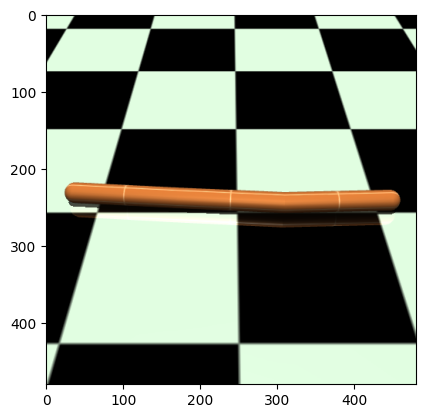

In [2]:
env = gym.make("Swimmer-v5", render_mode='rgb_array')
print("Action space: ", env.action_space)
print("State space: ", env.observation_space)

env.reset()
plt.imshow(env.render())

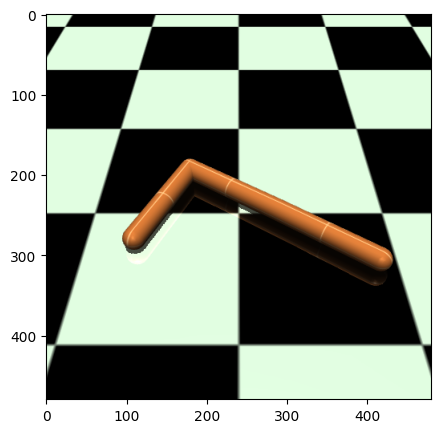

In [8]:
# policy = LinearPolicy(env.observation_space.shape[0], env.action_space.shape[0])

plt.figure(figsize=(5, 5))
display.clear_output(wait=True)
TIME_LIMIT = 150

state, _ = env.reset()
for t in range(TIME_LIMIT):
    plt.gca().clear()

    # action = policy.get_action(state) 
    action = np.random.uniform(-1, 1, 2)
    state, reward, terminated, _, _ = env.step(action)
    plt.imshow(env.render())

    display.display(plt.gcf())
    display.clear_output(wait=True)

    if terminated:
        print("Well done!")
        break
else:
    print("Time limit exceeded. Try again.")

display.clear_output(wait=True)

In [18]:
import numpy as np

env = gym.make("Swimmer-v5")
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]

def linear_policy(theta, x):
    x = np.asarray(x)
    action = theta @ x  # shape (2,) для Swimmer
    return np.clip(action, env.action_space.low, env.action_space.high)


def rollout(env, policy_fn, max_steps=1000):
    obs, _ = env.reset()
    total_reward = 0.0
    for _ in range(max_steps):
        action = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break
    return total_reward

def brs(env, alpha=0.02, nu=0.03, N=16, iterations=100):
    theta = np.zeros((act_dim, obs_dim))  # параметр матрицы действий
    for j in range(iterations):
        deltas = np.random.randn(N, act_dim, obs_dim)
        rewards_pos = np.zeros(N)
        rewards_neg = np.zeros(N)

        for k in range(N):
            theta_plus = theta + nu * deltas[k]
            theta_minus = theta - nu * deltas[k]

            rewards_pos[k] = rollout(env, lambda x: linear_policy(theta_plus, x))
            rewards_neg[k] = rollout(env, lambda x: linear_policy(theta_minus, x))

        # Оценка градиента
        step = np.zeros_like(theta)
        for k in range(N):
            step += (rewards_pos[k] - rewards_neg[k]) * deltas[k]

        theta += (alpha / N) * step
        avg_reward = np.mean(rewards_pos + rewards_neg)
        print(f"Iteration {j+1}, avg reward: {avg_reward:.2f}")

    return theta

# Обучаем
theta_opt = brs(env, iterations=50)

# Тестируем
total = rollout(env, lambda x: linear_policy(theta_opt, x))
print(f"Тестовое вознаграждение после обучения: {total:.2f}")

Iteration 1, avg reward: -3.40
Iteration 2, avg reward: 48.31
Iteration 3, avg reward: 56.75
Iteration 4, avg reward: 204.53
Iteration 5, avg reward: 245.65
Iteration 6, avg reward: 219.49
Iteration 7, avg reward: 485.51
Iteration 8, avg reward: 524.90
Iteration 9, avg reward: 567.68
Iteration 10, avg reward: 613.11
Iteration 11, avg reward: 643.95
Iteration 12, avg reward: 663.32
Iteration 13, avg reward: 675.99
Iteration 14, avg reward: 681.89
Iteration 15, avg reward: 687.83
Iteration 16, avg reward: 691.21
Iteration 17, avg reward: 688.42
Iteration 18, avg reward: 697.19
Iteration 19, avg reward: 701.89
Iteration 20, avg reward: 705.48
Iteration 21, avg reward: 703.75
Iteration 22, avg reward: 704.06
Iteration 23, avg reward: 705.87
Iteration 24, avg reward: 704.29
Iteration 25, avg reward: 707.02
Iteration 26, avg reward: 708.48
Iteration 27, avg reward: 705.60
Iteration 28, avg reward: 705.82
Iteration 29, avg reward: 707.59
Iteration 30, avg reward: 708.38
Iteration 31, avg rewa

In [ ]:
env = gym.make("Swimmer-v5", render_mode="human")

def watch_agent(env, theta, max_steps=1000):
    obs, _ = env.reset()
    total_reward = 0.0

    for _ in range(max_steps):
        env.render()  # для Gym >= 0.26 это можно опустить, render_mode уже задан
        action = linear_policy(theta, obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break

    print(f"🎮 Вознаграждение за просмотренный эпизод: {total_reward:.2f}")
    env.close()

theta_opt = brs(env, iterations=50)
watch_agent(env, theta_opt)

/Users/sciwake/github/avenv/lib/python3.13/site-packages/glfw/__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


Iteration 1, avg reward: -1.36


In [13]:
class LinearPolicy:
    def __init__(self, state_dim=None, action_dim=None, weights=None):
        self.weights = np.zeros((state_dim, action_dim)) if weights is None else weights

    def get_action(self, state):
        return self.weights.T @ state

    def update_weights(self, weights):
        self.weights = weights


def evaluate_policy(env, policy, rollout_length=250):
    state, _ = env.reset()
    episode_reward = 0
    for i in range(rollout_length):
        action = policy.get_action(state)
        next_s, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        state = next_s
        if terminated or truncated:
            break

    return episode_reward

In [ ]:
def rollout(env, policy_fn, max_steps=1000):
    obs, _ = env.reset()
    total_reward = 0.0
    for _ in range(max_steps):
        action = policy_fn(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break
    return total_reward


In [18]:
def basic_random_search(env, policy, alpha=0.02, nu=0.03, N=16, iterations=50, rollout_length=250):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    theta = policy.weights.copy()  # текущие параметры
    for i in range(iterations):
        deltas = np.random.randn(N, state_dim, action_dim)
        rewards_pos = np.zeros(N)
        rewards_neg = np.zeros(N)

        for k in range(N):
            theta_plus = theta + nu * deltas[k]
            theta_minus = theta - nu * deltas[k]
        
            policy_plus = LinearPolicy(state_dim, action_dim, weights=theta_plus)
            policy_minus = LinearPolicy(state_dim, action_dim, weights=theta_minus)
        
            rewards_pos[k] = evaluate_policy(env, policy_plus, rollout_length)
            rewards_neg[k] = evaluate_policy(env, policy_minus, rollout_length)


        # Возврат к текущему положению перед обновлением
        # policy.update_weights(theta)

        # Градиентное обновление
        step = sum((rewards_pos[k] - rewards_neg[k]) * deltas[k] for k in range(N))
        theta += (alpha / N) * step
        policy.update_weights(theta)

        avg_reward = np.mean(rewards_pos + rewards_neg)
        print(f"Iteration {i+1}: Avg reward = {avg_reward:.2f}")

    return theta


In [19]:
# import gym
import numpy as np
env = gym.make("Swimmer-v5", render_mode='rgb_array')

# Инициализируем политику
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
policy = LinearPolicy(state_dim=state_dim, action_dim=action_dim)

# Обучаем
basic_random_search(env, policy, iterations=50)


Iteration 1: Avg reward = -0.63
Iteration 2: Avg reward = 15.22
Iteration 3: Avg reward = 55.03
Iteration 4: Avg reward = 55.67
Iteration 5: Avg reward = 56.27
Iteration 6: Avg reward = 56.73
Iteration 7: Avg reward = 56.47
Iteration 8: Avg reward = 57.92
Iteration 9: Avg reward = 58.60
Iteration 10: Avg reward = 58.31
Iteration 11: Avg reward = 58.18
Iteration 12: Avg reward = 57.16
Iteration 13: Avg reward = 59.27
Iteration 14: Avg reward = 59.20
Iteration 15: Avg reward = 58.99
Iteration 16: Avg reward = 58.03
Iteration 17: Avg reward = 54.97
Iteration 18: Avg reward = 58.61
Iteration 19: Avg reward = 59.24
Iteration 20: Avg reward = 60.82
Iteration 21: Avg reward = 61.45
Iteration 22: Avg reward = 62.63
Iteration 23: Avg reward = 63.20
Iteration 24: Avg reward = 64.20
Iteration 25: Avg reward = 65.48
Iteration 26: Avg reward = 65.61
Iteration 27: Avg reward = 62.53
Iteration 28: Avg reward = 64.77
Iteration 29: Avg reward = 58.53
Iteration 30: Avg reward = 63.91
Iteration 31: Avg r

array([[-0.57206581, -0.14475844],
       [ 0.28021399,  0.33452417],
       [ 0.2075768 , -0.62105927],
       [-0.14214506,  0.23692928],
       [ 0.26868722, -0.30777568],
       [ 0.01599145,  0.38799969],
       [-0.10518293,  0.36090831],
       [-0.09010967, -0.19649287]])

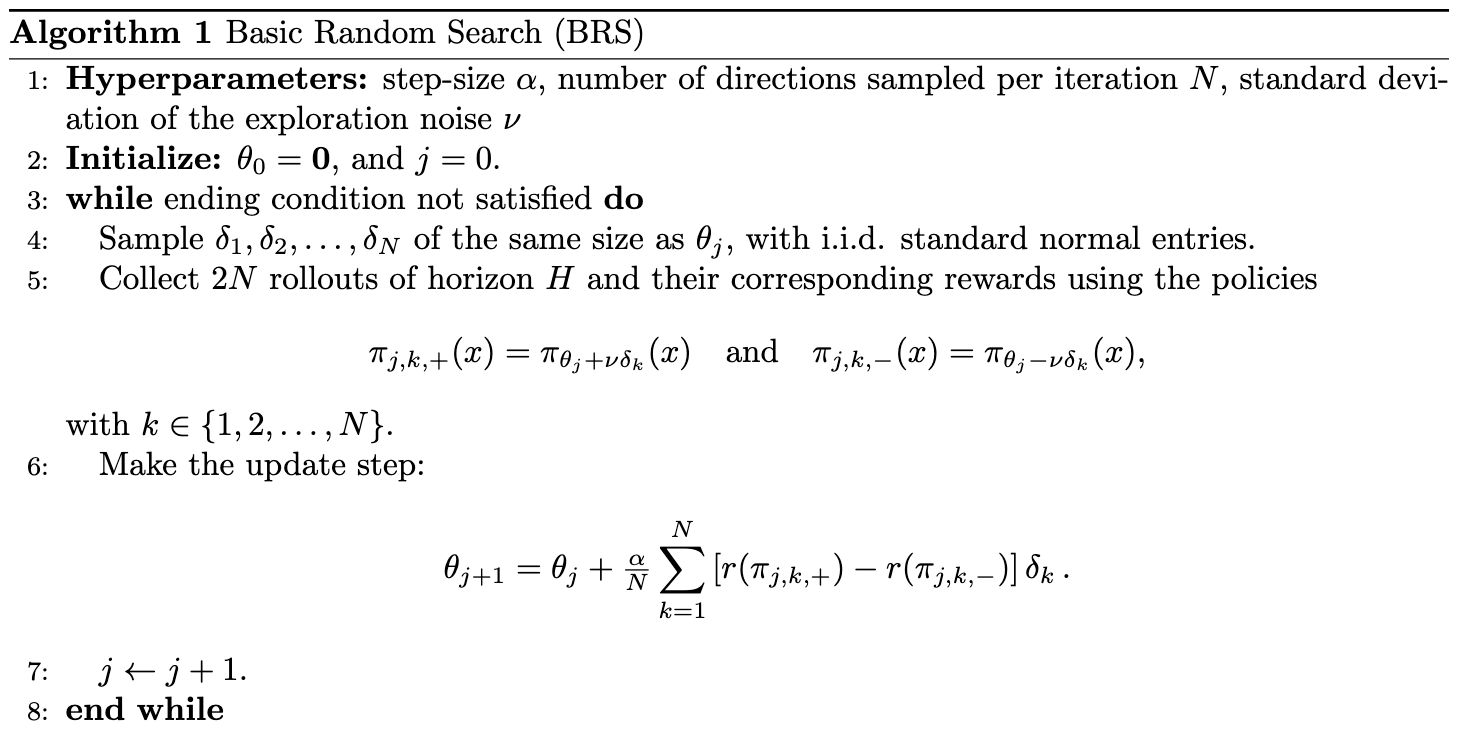

In [ ]:
import gymnasium as gym
import numpy as np
import time
import matplotlib.pyplot as plt # Keep plotting import

# Ensure you have gymnasium and mujoco installed:
# pip install gymnasium[mujoco]

def run_rollout(policy_params, env, horizon, render=False, sleep_time=0.01):
    """
    Runs one episode (rollout) using the provided linear policy parameters.
    Optionally renders the environment.

    Args:
        policy_params (np.ndarray): The parameters (theta) of the linear policy.
                                    Shape (action_dim, observation_dim).
        env (gymnasium.Env): The environment instance.
        horizon (int): The maximum number of steps per episode.
        render (bool): If True, renders the environment.
        sleep_time (float): Time to pause between steps if rendering.

    Returns:
        float: The total reward accumulated during the episode.
    """
    obs, info = env.reset()
    total_reward = 0.0
    done = False
    truncated = False
    step = 0

    while not done and not truncated and step < horizon:
        if render:
            env.render()
            time.sleep(sleep_time) # Slow down rendering for observation

        # Linear policy: action = theta @ observation
        obs_flat = obs.flatten()
        action = policy_params @ obs_flat
        action = np.clip(action, env.action_space.low, env.action_space.high)

        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward
        step += 1

    if render:
        print(f"Visualization Episode Reward: {total_reward:.2f}")
    return total_reward

def visualize_policy(policy_params, env_name, horizon, num_episodes=3, sleep_time=0.02):
    """Creates a rendering environment and runs the policy for visualization."""
    print("\n--- Visualizing Trained Policy ---")
    # Create a new environment instance specifically for rendering
    vis_env = gymnasium.make(env_name, render_mode="human")
    print(f"Running {num_episodes} episodes for visualization...")

    rewards = []
    for i in range(num_episodes):
        print(f"Starting visualization episode {i+1}/{num_episodes}")
        reward = run_rollout(policy_params, vis_env, horizon, render=True, sleep_time=sleep_time)
        rewards.append(reward)
        time.sleep(0.5) # Pause slightly between episodes

    print("-" * 30)
    print(f"Average reward during visualization: {np.mean(rewards):.2f}")
    vis_env.close()
    print("--- Visualization Complete ---")


# --- Algorithm 1: Basic Random Search (BRS) ---

# 1. Hyperparameters
alpha = 0.02
N = 10
nu = 0.05
max_iterations = 500 # Increase iterations for potentially better results

# --- Environment Setup ---
env_name = "Humanoid-v5"
# Create a non-rendering env for fast training
env = gym.make(env_name)
horizon = env.spec.max_episode_steps

obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

print(f"Environment: {env_name}")
print(f"Observation Dim: {obs_dim}")
print(f"Action Dim: {action_dim}")
print(f"Horizon H: {horizon}")
print(f"Hyperparameters: alpha={alpha}, N={N}, nu={nu}")
print("-" * 30)

# 2. Initialize
theta = np.zeros((action_dim, obs_dim))
iteration_rewards = []

# --- Main Training Loop ---
start_time = time.time()
print(f"Starting BRS Training for {max_iterations} iterations...")

for j in range(max_iterations):
    deltas = np.random.randn(N, action_dim, obs_dim)
    rewards_plus = np.zeros(N)
    rewards_minus = np.zeros(N)

    for k in range(N):
        theta_plus = theta + nu * deltas[k]
        # Use the non-rendering env for speed during training rollouts
        rewards_plus[k] = run_rollout(theta_plus, env, horizon, render=False)

        theta_minus = theta - nu * deltas[k]
        rewards_minus[k] = run_rollout(theta_minus, env, horizon, render=False)

    update_gradient_estimate = np.zeros_like(theta)
    for k in range(N):
        update_gradient_estimate += (rewards_plus[k] - rewards_minus[k]) * deltas[k]
    
    theta = theta + (alpha / N) * update_gradient_estimate

    # --- Monitoring ---
    # Evaluate current policy in the non-rendering env
    current_reward = run_rollout(theta, env, horizon, render=False)
    iteration_rewards.append(current_reward)
    avg_reward_last_10 = np.mean(iteration_rewards[-10:])

    if (j + 1) % 50 == 0 or j == max_iterations - 1: # Print less frequently
        print(f"Iter {j+1}/{max_iterations} | "
              f"Avg Reward (Current): {current_reward:.2f} | "
              f"Avg Reward (Last 10): {avg_reward_last_10:.2f} | "
              f"Time: {time.time() - start_time:.1f}s")

# --- End Training ---
env.close() # Close the training environment
end_time = time.time()
print("-" * 30)
print(f"Training finished in {end_time - start_time:.2f} seconds.")
print(f"Final average reward during training (last 10 iterations): {np.mean(iteration_rewards[-10:]):.2f}")

# --- Optional: Evaluate final policy multiple times (no rendering) ---
print("\nEvaluating final policy (no rendering)...")
eval_env = gymnasium.make(env_name) # Separate env for final eval
final_rewards = []
num_eval_episodes = 20
for _ in range(num_eval_episodes):
    final_rewards.append(run_rollout(theta, eval_env, horizon, render=False))
print(f"Average reward over {num_eval_episodes} evaluation episodes: {np.mean(final_rewards):.2f} +/- {np.std(final_rewards):.2f}")
eval_env.close()


# --- Visualize the final learned policy ---
visualize_policy(theta, env_name, horizon, num_episodes=5, sleep_time=0.03)


# --- Plotting Training Curve ---
plt.figure(figsize=(10, 5))
plt.plot(iteration_rewards, label='Reward per Iteration')
# Add a rolling average
if len(iteration_rewards) >= 10:
    rolling_avg = np.convolve(iteration_rewards, np.ones(10)/10, mode='valid')
    plt.plot(np.arange(9, len(iteration_rewards)), rolling_avg, label='10-iteration Rolling Average', alpha=0.7, color='red')
plt.xlabel("Iteration")
plt.ylabel("Average Reward (Current Policy)")
plt.title(f"BRS Training Curve for {env_name}")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# from gym.wrappers.record_video import RecordVideo
import os

video_dir = "./videos"
os.makedirs(video_dir, exist_ok=True)

env = gym.make(env_name, render_mode="rgb_array")
env = RecordVideo(env, video_folder=video_dir, episode_trigger=lambda x: True)

# Запуск одного эпизода
run_rollout(theta, env, horizon)

env.close()
print(f"Видео сохранено в: {video_dir}")

In [ ]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.
import sys
from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[0]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

### Что делает *line search*?
> В этой статье не используется линейный поиск, можно реализовать.

Представь, что ты выбрал случайное направление $u$ в пространстве параметров. Тогда:

* Метод ищет $\alpha$, такое, что $\theta + \alpha u$ даёт наибольшее значение функции (т.е. награды).
* Это и называется **line search**: по выбранному направлению $u$ ищется **лучшее значение шага $\alpha$**.